# Logistic Regression Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

C:\Users\Zeyad\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [5]:
# Load dataset
df = pd.read_csv('heart.csv')

# Quick sanity checks
df.head()     # first 5 rows


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
df.info()  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.describe().transpose()  # basic stats

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [13]:
# Separate features and label
X = df.drop(columns=['target'])  # all input features
y = df['target']                 # output label

# Sanity check
print(X.shape, y.shape)
print(y.value_counts())

(303, 13) (303,)
target
1    165
0    138
Name: count, dtype: int64


**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,        # 80/20 split
    random_state=101,      # reproducibility
    stratify=y            # VERY important for classification
)

print(X_train.shape, X_test.shape)

(272, 13) (31, 13)


**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage (data knowledge leaking from the test set).**

In [16]:
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

**TASK: Create a Logistic Regression model

In [17]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(
    random_state=42,
    max_iter=1000  # avoid convergence issues
)

# Train
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Coeffecients

**TASK: Report back the model's coefficients.**

In [18]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(coeff_df.sort_values(by='Coefficient', key=abs, ascending=False))

     Feature  Coefficient
2         cp     0.880960
11        ca    -0.872636
1        sex    -0.790055
12      thal    -0.622172
7    thalach     0.605213
9    oldpeak    -0.583074
8      exang    -0.403474
10     slope     0.344300
4       chol    -0.222951
6    restecg     0.203969
3   trestbps    -0.199281
0        age    -0.116616
5        fbs    -0.015409


## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

Confusion Matrix Array:
[[12  2]
 [ 4 13]]


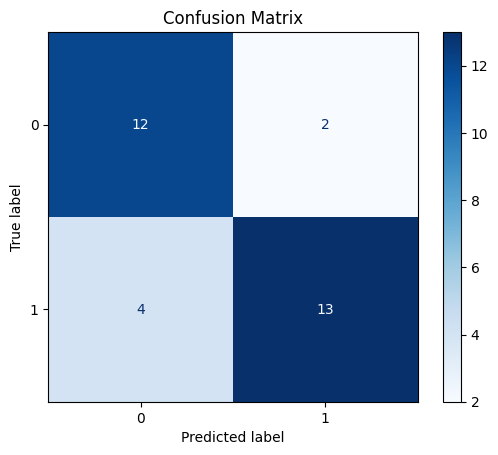


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.86      0.80        14
           1       0.87      0.76      0.81        17

    accuracy                           0.81        31
   macro avg       0.81      0.81      0.81        31
weighted avg       0.81      0.81      0.81        31



In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Predict on test set
y_pred = model.predict(X_test_scaled)

# 1) Confusion Matrix Array
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix Array:")
print(cm)

# 2) Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# 3) Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### Performance Curves

**TASK: Create the ROC Curve.**

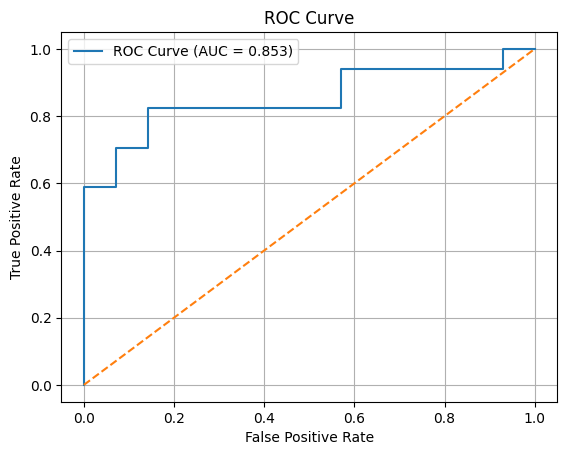

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # random classifier baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

The ROC curve shows good discriminative ability with an AUC of 0.853, indicating that the model can effectively distinguish between patients with and without heart disease. The curve demonstrates strong performance at low false positive rates, achieving relatively high true positive rates early on, which is desirable in medical applications. However, the step-like nature of the curve suggests a limited dataset size, and the model still exhibits a trade-off between sensitivity and specificity. Threshold tuning would be necessary depending on clinical priorities, particularly to minimize false negatives.

**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [21]:
# New patient data
new_patient = pd.DataFrame([{
    'age': 48.0,
    'sex': 0.0,
    'cp': 2.0,
    'trestbps': 130.0,
    'chol': 275.0,
    'fbs': 0.0,
    'restecg': 1.0,
    'thalach': 139.0,
    'exang': 0.0,
    'oldpeak': 0.2,
    'slope': 2.0,
    'ca': 0.0,
    'thal': 2.0
}])

# Make sure column order matches training data
new_patient = new_patient[X.columns]

# Scale using the SAME scaler fitted on training data
new_patient_scaled = scaler.transform(new_patient)

# Predict class
prediction = model.predict(new_patient_scaled)[0]

# Predict probabilities
prediction_proba = model.predict_proba(new_patient_scaled)[0]

print("Predicted class:", prediction)
print("Probability of no heart disease (class 0):", prediction_proba[0])
print("Probability of heart disease (class 1):", prediction_proba[1])

Predicted class: 1
Probability of no heart disease (class 0): 0.019201884891097976
Probability of heart disease (class 1): 0.980798115108902


In [22]:
if prediction == 1:
    print(f"\nThe model predicts: HEART DISEASE")
    print(f"Model confidence: {prediction_proba[1]*100:.2f}%")
else:
    print(f"\nThe model predicts: NO HEART DISEASE")
    print(f"Model confidence: {prediction_proba[0]*100:.2f}%")


The model predicts: HEART DISEASE
Model confidence: 98.08%


The model predicts that the patient has heart disease with a high confidence of 98.08%. While this suggests a strong classification, such a high probability should be interpreted with caution. The overall model performance (AUC ≈ 0.85) indicates good but not perfect discrimination, and logistic regression models can be overconfident in their probability estimates. Additionally, the patient’s feature profile contains mixed indicators, suggesting that further validation or calibration of the model may be necessary before relying on this prediction in a clinical setting.